# Exploratory Data Analysis: Ames Housing District

## Introduction

This EDA will examine the Ames Housing dataset to better understand the variables
and how they relate to one another. It will be used to determine which variables 
will be most useful for predicting residential home sale prices for Ames, Iowa. The
EDA will examine the types and distributions of variables, missing values, redundant features, relationships between variables, and outliers. These findings 
will be used to make decisions about model building in later steps of this project. 

## Description of Dataset

The dataset used for this project is the Ames Housing dataset. It contains information about residential property sales in Ames, Iowa. Each observation includes characteristics the describe the property that was sold as well as the sales price. Further observations about the dataset will be made throughout this EDA when it is examined closer. 

This dataset was obtained from the CMU Statisitics & Data Science Data Repository.

## 1. Import libraries

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the data

The dataset will be loaded into a DataFrame. I am using the shape() function to understand the size of the dataset.

In [2]:
df = pd.read_csv("ames-housing.csv")

df.shape

(2930, 82)

### 2a. Observations

There are 2,930 observations and 82 variables in this dataset. 

## 3. Examine the structure of the dataset.

Before analyzing individual variables, I want to look at the overall structure of the data. This lets me see the variables that are present, missing values, and get a better initial understanding of the data. 

In [3]:
df.head()

,Order,PID,MS.SubClass,MS.Zoning,Lot.Frontage,Lot.Area,Street,Alley,Lot.Shape,Land.Contour,...,Pool.Area,Pool.QC,Fence,Misc.Feature,Misc.Val,Mo.Sold,Yr.Sold,Sale.Type,Sale.Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS.SubClass      2930 non-null   int64  
 3   MS.Zoning        2930 non-null   object 
 4   Lot.Frontage     2440 non-null   float64
 5   Lot.Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot.Shape        2930 non-null   object 
 9   Land.Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot.Config       2930 non-null   object 
 12  Land.Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition.1      2930 non-null   object 
 15  Condition.2      2930 non-null   object 
 16  Bldg.Type        2930 non-null   object 
 17  House.Style   

### 3a. Observations

There are many characteristics described for each observation. This dataset contains numerical and categorical variables. The final column 'SalePrice' will act as the target variable for this project. 

There are numerous missing values. These will need to be further investigated during the cleaning and feature engineering phases of this project. 

## 4. Identify Variable Types

Variable types will be determined so that appropriate analysis tools can be used. Numerical variables will be examined using descriptive statisitics, distributions, and correlations. While categorical variables can be examined using frequency counts and visualizations. This step will help determine which EDA techniques are used for further examination of each variable. 

In [5]:
df.dtypes.value_counts()

object     43
int64      28
float64    11
Name: count, dtype: int64

In [6]:
# set variable for numeric features.
numeric_features = df.select_dtypes(include="number").columns
numeric_features

Index(['Order', 'PID', 'MS.SubClass', 'Lot.Frontage', 'Lot.Area',
       'Overall.Qual', 'Overall.Cond', 'Year.Built', 'Year.Remod.Add',
       'Mas.Vnr.Area', 'BsmtFin.SF.1', 'BsmtFin.SF.2', 'Bsmt.Unf.SF',
       'Total.Bsmt.SF', 'X1st.Flr.SF', 'X2nd.Flr.SF', 'Low.Qual.Fin.SF',
       'Gr.Liv.Area', 'Bsmt.Full.Bath', 'Bsmt.Half.Bath', 'Full.Bath',
       'Half.Bath', 'Bedroom.AbvGr', 'Kitchen.AbvGr', 'TotRms.AbvGrd',
       'Fireplaces', 'Garage.Yr.Blt', 'Garage.Cars', 'Garage.Area',
       'Wood.Deck.SF', 'Open.Porch.SF', 'Enclosed.Porch', 'X3Ssn.Porch',
       'Screen.Porch', 'Pool.Area', 'Misc.Val', 'Mo.Sold', 'Yr.Sold',
       'SalePrice'],
      dtype='object')

In [7]:
# set variable for categorical features
categorical_features = df.select_dtypes(include="object").columns
categorical_features

Index(['MS.Zoning', 'Street', 'Alley', 'Lot.Shape', 'Land.Contour',
       'Utilities', 'Lot.Config', 'Land.Slope', 'Neighborhood', 'Condition.1',
       'Condition.2', 'Bldg.Type', 'House.Style', 'Roof.Style', 'Roof.Matl',
       'Exterior.1st', 'Exterior.2nd', 'Mas.Vnr.Type', 'Exter.Qual',
       'Exter.Cond', 'Foundation', 'Bsmt.Qual', 'Bsmt.Cond', 'Bsmt.Exposure',
       'BsmtFin.Type.1', 'BsmtFin.Type.2', 'Heating', 'Heating.QC',
       'Central.Air', 'Electrical', 'Kitchen.Qual', 'Functional',
       'Fireplace.Qu', 'Garage.Type', 'Garage.Finish', 'Garage.Qual',
       'Garage.Cond', 'Paved.Drive', 'Pool.QC', 'Fence', 'Misc.Feature',
       'Sale.Type', 'Sale.Condition'],
      dtype='object')

### 4a. Observations

Based on Pandas indentification of variable types, there are 39 numeric features and 43 categorical features. I will need to be careful during the analysis stage of this project as some of the features it has labels as numeric could also be useful as a categorical feature during analysis. For example, number of bedrooms. 

## 5. Univariate EDA -- Numerical Features

Univariate EDA will be performed to examined each variable individually. For the numeric features, descriptive statistics and graphical representations will be used to understand the center and distributions of the data. Histograms will be used to examine the shape of the distribution, while boxplots will help identify outliers. This step is important because outliers could have a large impact on model accuracy. 

### 5a. Descriptive Statistics

In [8]:
df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Order,2930.0,1.465500e+03,8.459625e+02,1.0,7.332500e+02,1465.5,2.197750e+03,2.930000e+03
PID,2930.0,7.144645e+08,1.887308e+08,526301100.0,5.284770e+08,535453620.0,9.071811e+08,1.007100e+09
MS.SubClass,2930.0,5.738737e+01,4.263802e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot.Frontage,2440.0,6.922459e+01,2.336533e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot.Area,2930.0,1.014792e+04,7.880018e+03,1300.0,7.440250e+03,9436.5,1.155525e+04,2.152450e+05
Overall.Qual,2930.0,6.094881e+00,1.411026e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall.Cond,2930.0,5.563140e+00,1.111537e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year.Built,2930.0,1.971356e+03,3.024536e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year.Remod.Add,2930.0,1.984267e+03,2.086029e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas.Vnr.Area,2907.0,1.018968e+02,1.791126e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03


In [9]:
# View target variable individually
df["SalePrice"].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

### 5a. Interpretations

The descriptive statistics show that the numerical variables have a wide range of scales and distributions. This shows considerable variability across the properties in the dataset. Based on the counts, there are some variables that have missing values and will need to be investigated further. There are also potential outliers that I can see from these values. Graphical analysis will be used to determine if outliers exist. 

### 5b. Distributions

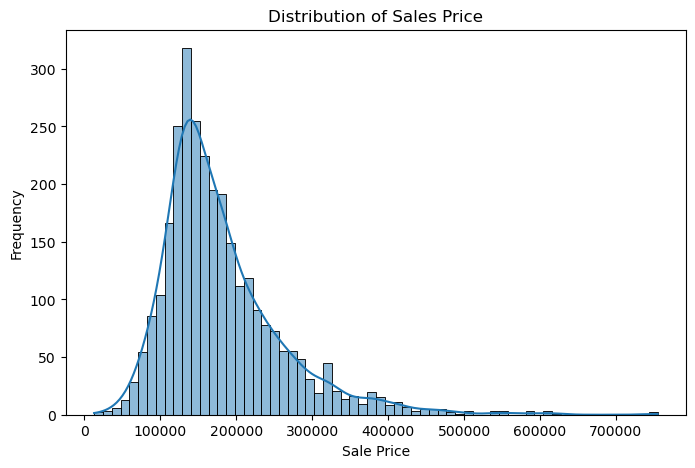

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution of Sales Price")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

### Interpretation of Target Variable Histogram

The distribution of "SalePrice" is positively skewed. The histogram shows a long tail extending to the right, with only a few properties selling for more than $500,000. Based on the distribution and the mean being higher than the median, there may be a high value outlier causing this shift in mean. This will need to be considered when developing the model. 

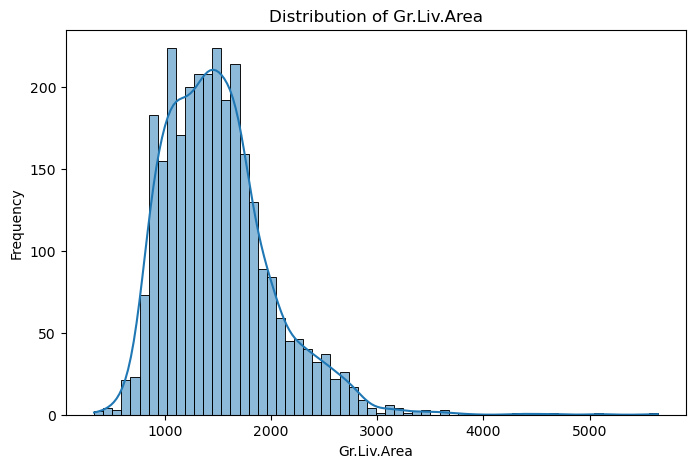

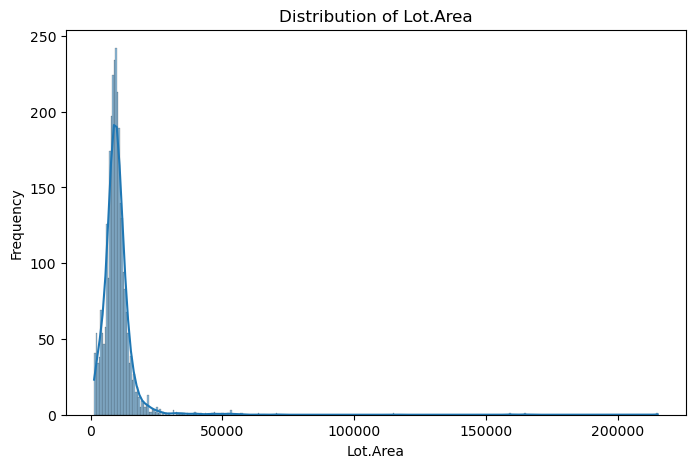

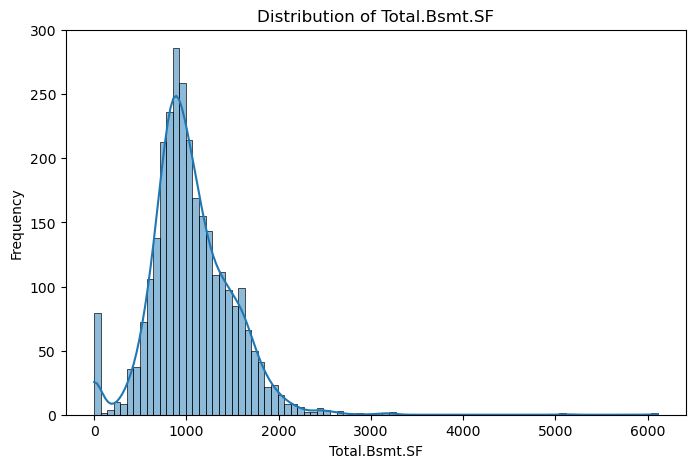

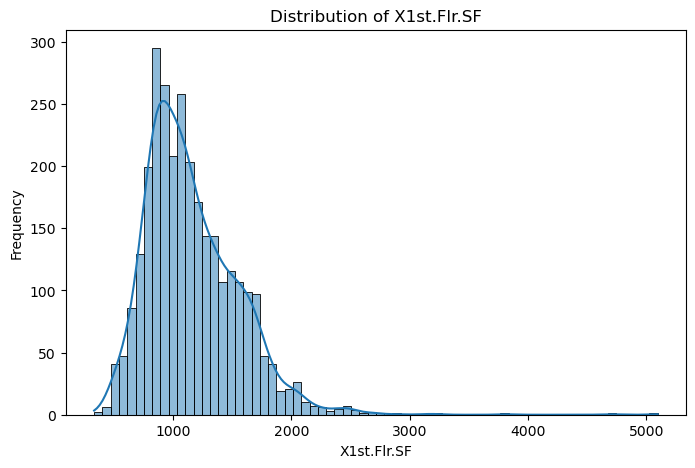

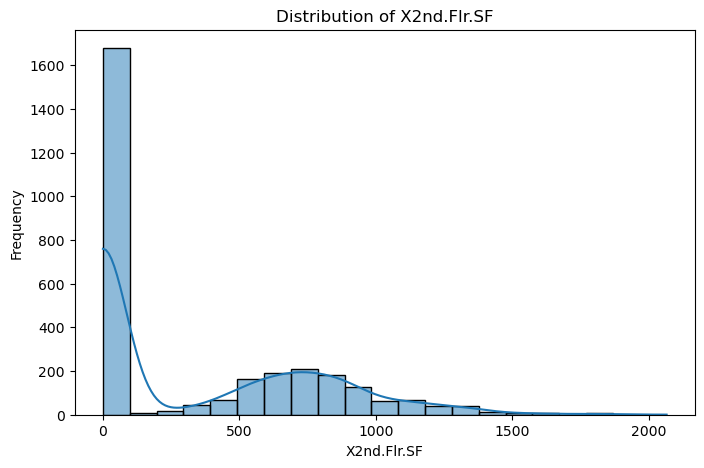

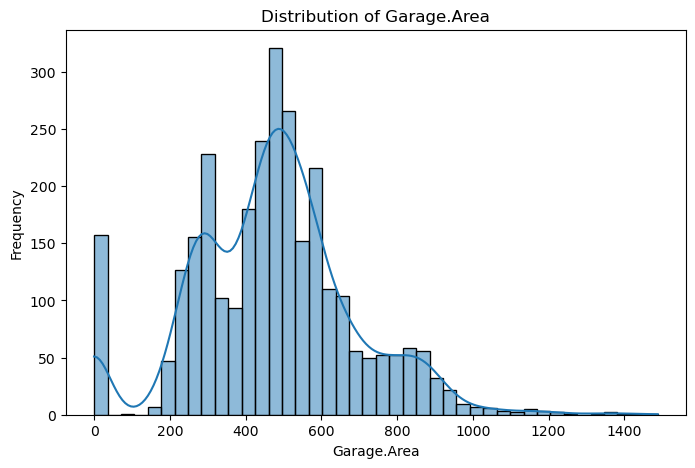

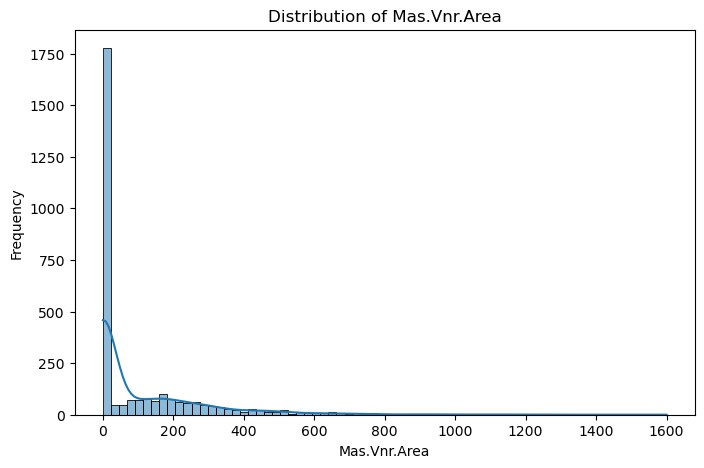

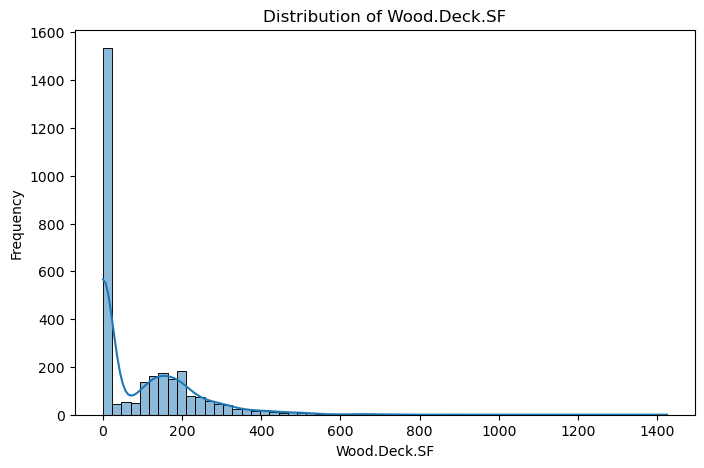

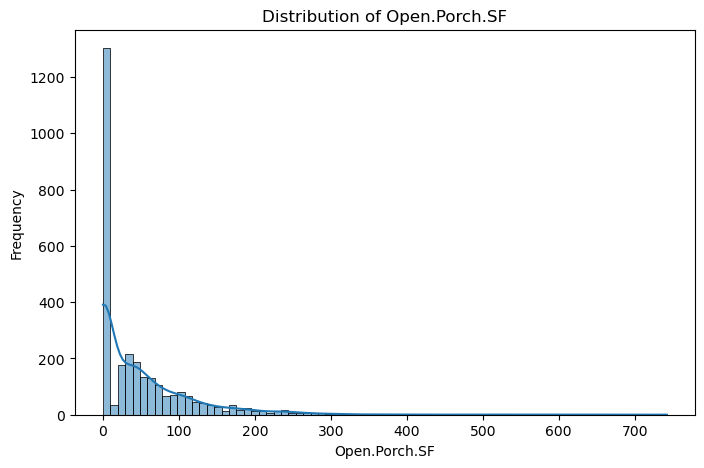

In [12]:
continuous_features = [
    "Gr.Liv.Area",
    "Lot.Area",
    "Total.Bsmt.SF",
    "X1st.Flr.SF",
    "X2nd.Flr.SF",
    "Garage.Area",
    "Mas.Vnr.Area",
    "Wood.Deck.SF",
    "Open.Porch.SF"
]

for feature in continuous_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[feature], kde=True)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

### Interpretations of other feature histograms

Only some of the variables were examined at this stage. The variables were chosen based on their potential ability to predict sale price. Other variables will be examined later if needed. 

The histograms show that the continuous housing features have a variety of distributions. 'Gr.Liv.Area', 'Total.Bsmt.SF' and 'X1st.Flr.SF' have right-skewed distributions. 'Lot.Area' is strongly right-skewed, indicating that most properties have smaller lot sizes. There could be some outliers here that need to be investigated. 'X2nd.Flr.SF', 'Garage.Area', 'Mas.Vnr.Area', 'Wood.Deck.SF' and 'Open.Porch.SF' all have large concentrations of observations at 0. This could indicate a large number of properties that do not have those features and may be looked at further or removed before modeling. 

### 5c. Outliers

Potential outliers need to be identified at this stage. Boxplots will be used to identify these outliers. All numeric features will not be examined at this point. I will start with variables that were already identified as potential issues. Extreme values need to be identified as they can have an impact on the regression model. 

In [13]:
def create_boxplot(data, feature, title=None):
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data[feature])
    
    if title is None:
        title = f"Boxplot of {feature}"
        
    plt.title(title)
    plt.xlabel(feature)
    plt.show()

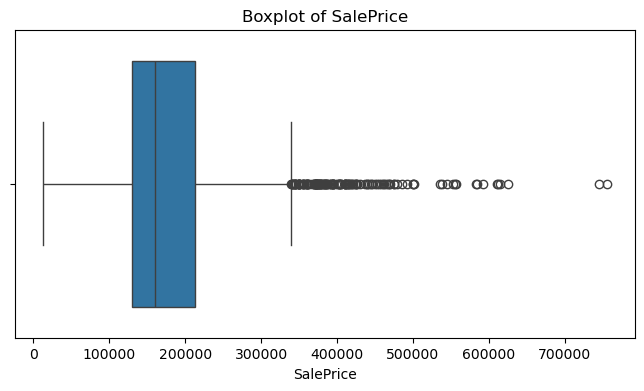

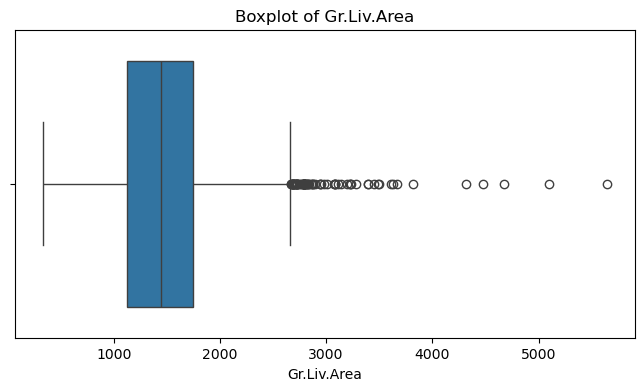

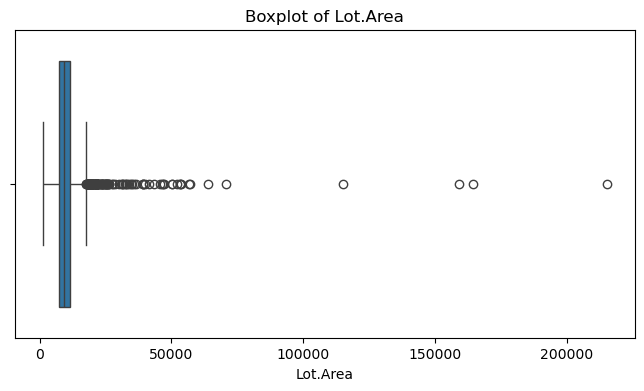

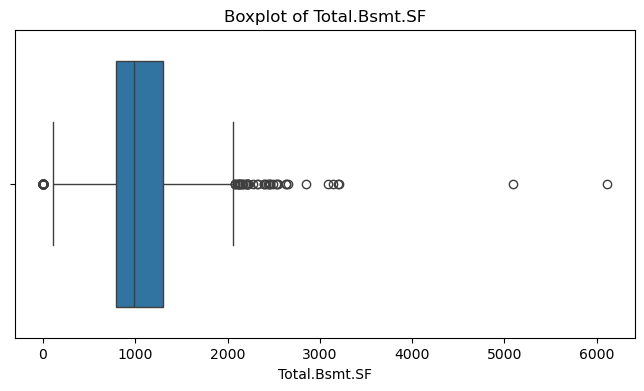

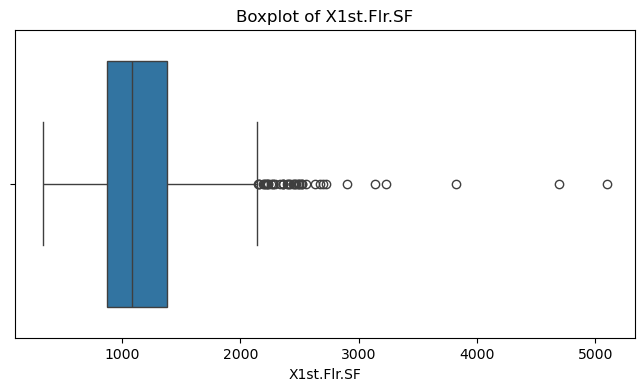

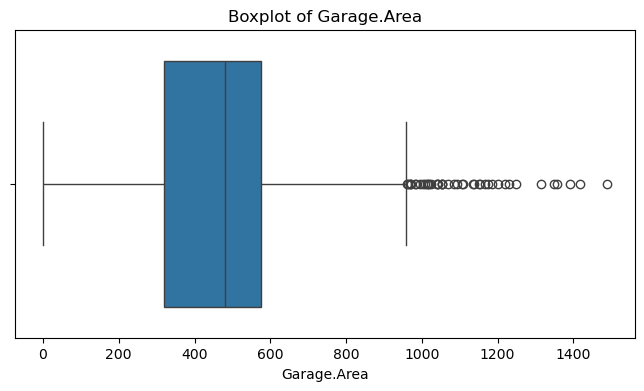

In [14]:
outlier_features = [
    "SalePrice",
    "Gr.Liv.Area",
    "Lot.Area",
    "Total.Bsmt.SF",
    "X1st.Flr.SF",
    "Garage.Area"
]

for feature in outlier_features:
    create_boxplot(df, feature)

### Interpretation of Potential Outliers

Based on the boxplots, I can tell there are numerous potential outliers. This does not necessarily mean they are problems at this point. All six of these features are consistent with the right skewed histograms for these features. These observations need to be examined further to determine their potential effect on the model. 

## 6. Univariate Categorical Analysis

Categorical variables need to be analyzed by examining their distributions and determining which categories are more or less common. This is important because not all of these features will remain in the dataset during the modeling phase. I will identify the number of different categories for each categorical feature.  Then bar charts will be used to visualize the frequency of each feature and determine its relevance for the model. 

In [16]:
for feature in categorical_features:
    print(f"{feature}: {df[feature].nunique()} categories")

MS.Zoning: 7 categories
Street: 2 categories
Alley: 2 categories
Lot.Shape: 4 categories
Land.Contour: 4 categories
Utilities: 3 categories
Lot.Config: 5 categories
Land.Slope: 3 categories
Neighborhood: 28 categories
Condition.1: 9 categories
Condition.2: 8 categories
Bldg.Type: 5 categories
House.Style: 8 categories
Roof.Style: 6 categories
Roof.Matl: 8 categories
Exterior.1st: 16 categories
Exterior.2nd: 17 categories
Mas.Vnr.Type: 4 categories
Exter.Qual: 4 categories
Exter.Cond: 5 categories
Foundation: 6 categories
Bsmt.Qual: 5 categories
Bsmt.Cond: 5 categories
Bsmt.Exposure: 4 categories
BsmtFin.Type.1: 6 categories
BsmtFin.Type.2: 6 categories
Heating: 6 categories
Heating.QC: 5 categories
Central.Air: 2 categories
Electrical: 5 categories
Kitchen.Qual: 5 categories
Functional: 8 categories
Fireplace.Qu: 5 categories
Garage.Type: 6 categories
Garage.Finish: 3 categories
Garage.Qual: 5 categories
Garage.Cond: 5 categories
Paved.Drive: 3 categories
Pool.QC: 4 categories
Fence: 4

In [17]:
for feature in categorical_features:
    print(f"\n{feature}")
    print(df[feature].value_counts())


MS.Zoning
MS.Zoning
RL         2273
RM          462
FV          139
RH           27
C (all)      25
I (all)       2
A (agr)       2
Name: count, dtype: int64

Street
Street
Pave    2918
Grvl      12
Name: count, dtype: int64

Alley
Alley
Grvl    120
Pave     78
Name: count, dtype: int64

Lot.Shape
Lot.Shape
Reg    1859
IR1     979
IR2      76
IR3      16
Name: count, dtype: int64

Land.Contour
Land.Contour
Lvl    2633
HLS     120
Bnk     117
Low      60
Name: count, dtype: int64

Utilities
Utilities
AllPub    2927
NoSewr       2
NoSeWa       1
Name: count, dtype: int64

Lot.Config
Lot.Config
Inside     2140
Corner      511
CulDSac     180
FR2          85
FR3          14
Name: count, dtype: int64

Land.Slope
Land.Slope
Gtl    2789
Mod     125
Sev      16
Name: count, dtype: int64

Neighborhood
Neighborhood
NAmes      443
CollgCr    267
OldTown    239
Edwards    194
Somerst    182
NridgHt    166
Gilbert    165
Sawyer     151
NWAmes     131
SawyerW    125
Mitchel    114
BrkSide    108
Cr

In [18]:
def create_countplot(data, feature, title=None):
    plt.figure(figsize=(10, 5))
    sns.countplot(data=data, x=feature, order=data[feature].value_counts().index)
    
    if title is None:
        title = f"Distribution of {feature}"
        
    plt.title(title)
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

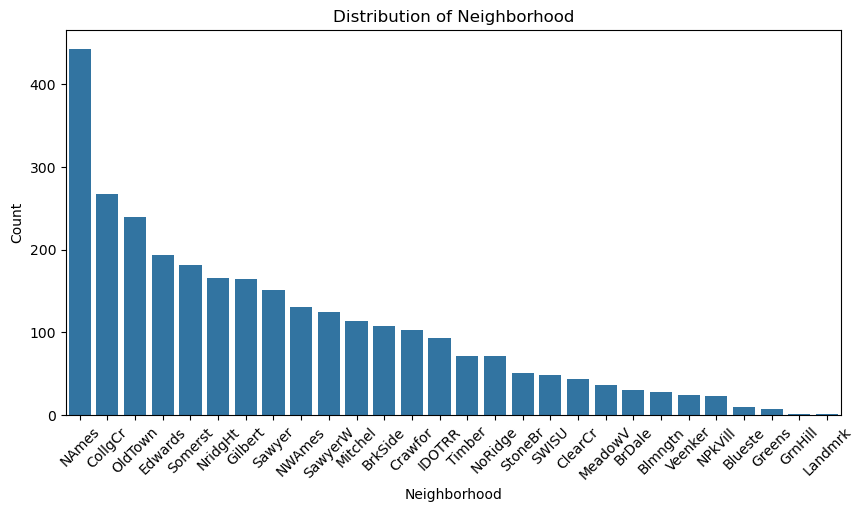

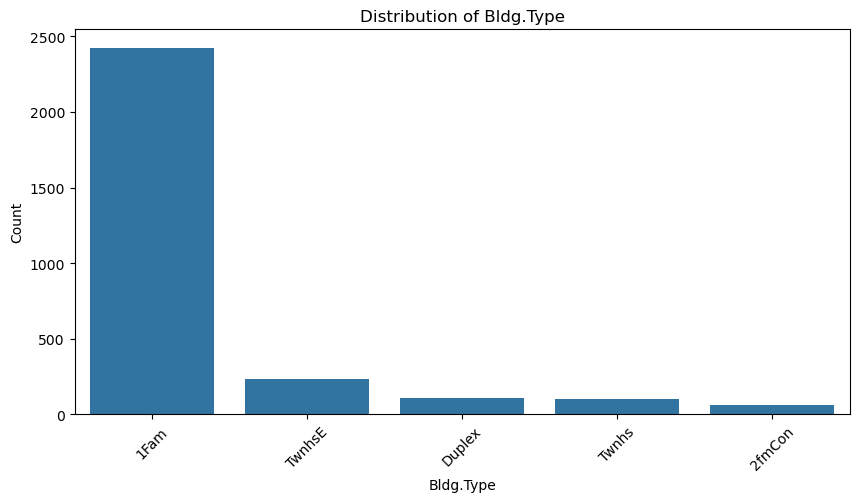

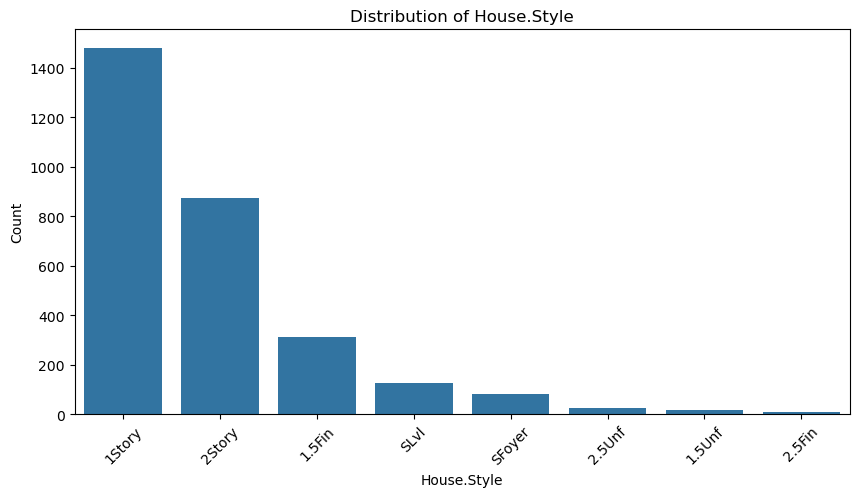

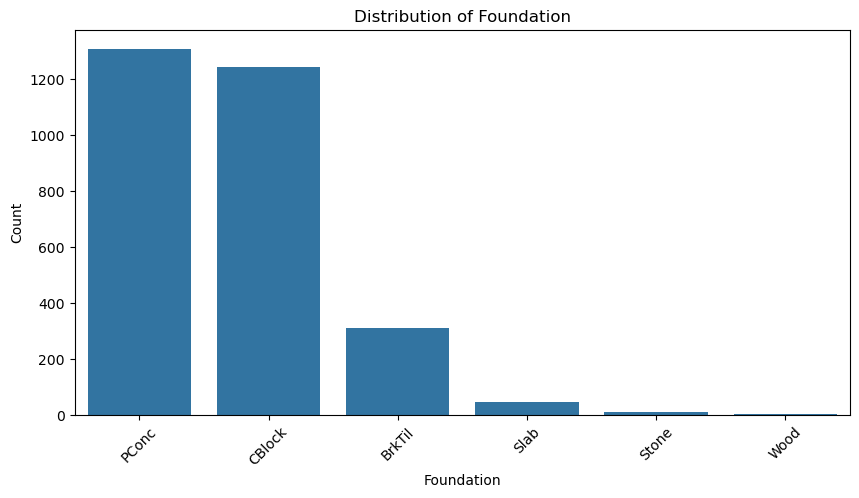

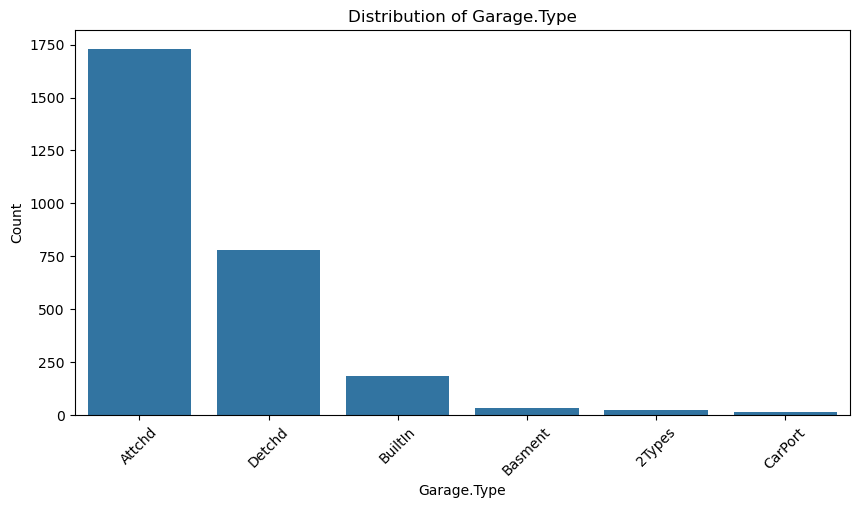

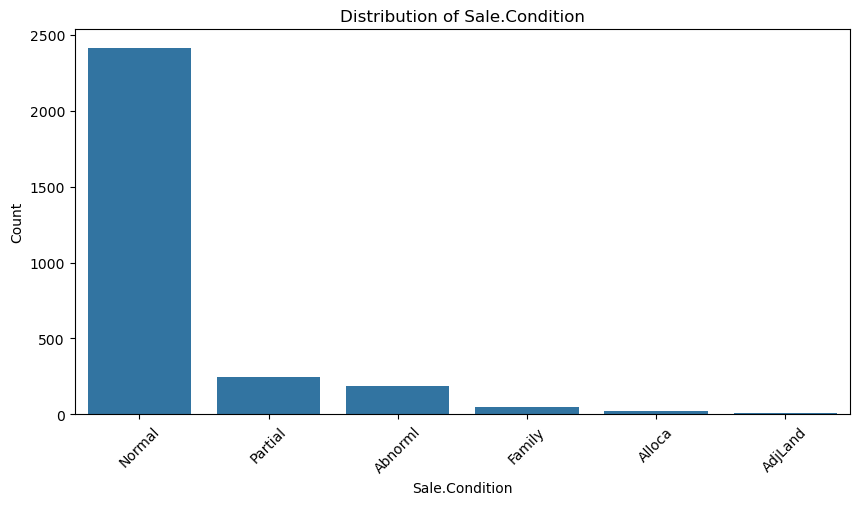

In [19]:
categorical_features_to_plot = [
    "Neighborhood",
    "Bldg.Type",
    "House.Style",
    "Foundation",
    "Garage.Type",
    "Sale.Condition"
]

for feature in categorical_features_to_plot:
    create_countplot(df, feature)

### Interpretation of Categorical Variables

The count plots show that the categorical features are not evenly distributed across their categories. This provides a good overview of the composition of the housing data. Categories that have few observations should be further examined to determine whether they will be useful for the model. 

## 7. Bivariate Analysis

This phase of the EDA will examine the relationship between two variables. This is used to identify patterns and relationships that may be important for understanding home sale prices. Numerical and Categorical features will be compared to 'SalePrice' (the target variable). At this time, I will break look at relationships with variables that are likely to effect the price. Further analysis will be completed later. 

Scatterplots will be be used for this using Seaborn's pairplot() function. 

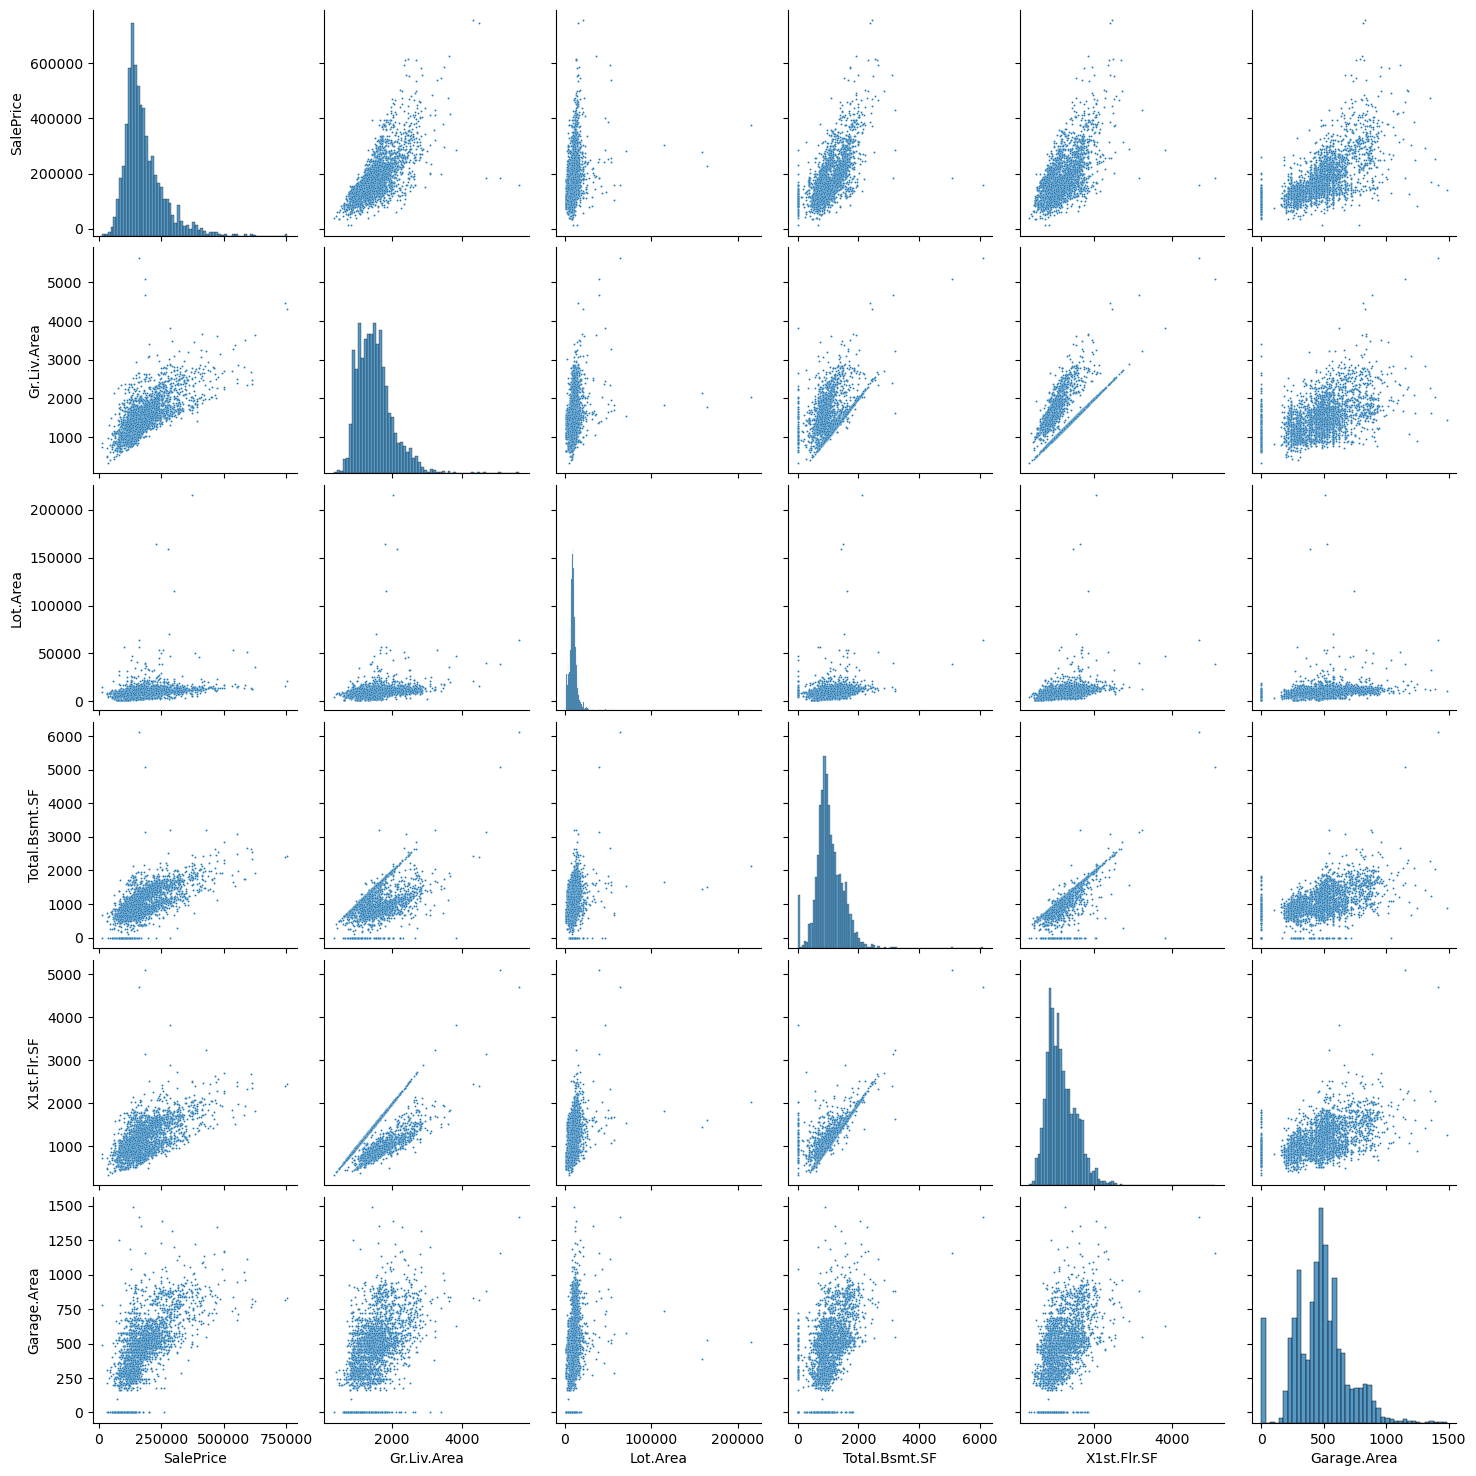

In [22]:
numerical_features = [
    "SalePrice",
    "Gr.Liv.Area",
    "Lot.Area",
    "Total.Bsmt.SF",
    "X1st.Flr.SF",
    "Garage.Area"
]

sns.pairplot(
    df[numerical_features],
    plot_kws={"s": 2}
)

plt.show()

### Interpretation of Numerical Variables and SalePrice.

The pairplot shows several positive relationships. 'Gr.Liv.Area', 'Total.Bsmt.SF' and 'X1st.Flr.SF' have fairly strong positive relationships with 'SalePrice'. This shows that larger areas are typically related with higher sale prices. 'Lot.Area' has a much weaker relationship with 'SalePrice', indicating that it does not have much impact on it. 

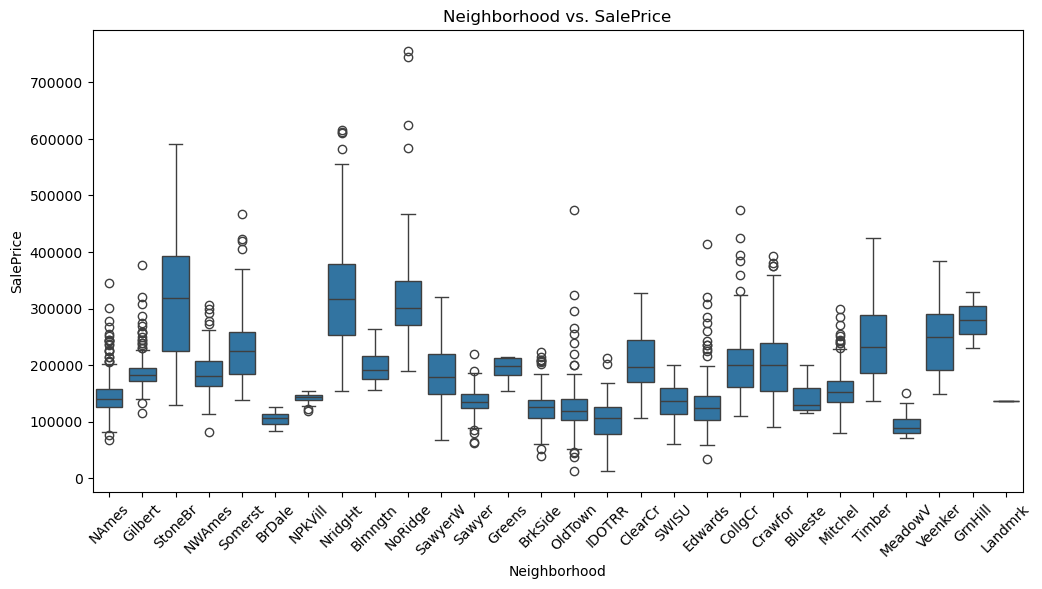

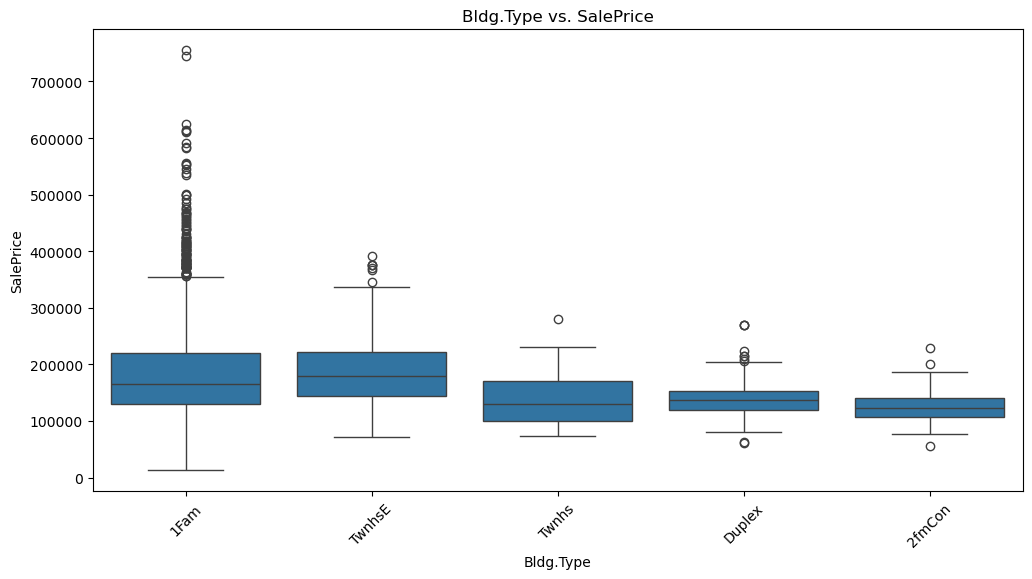

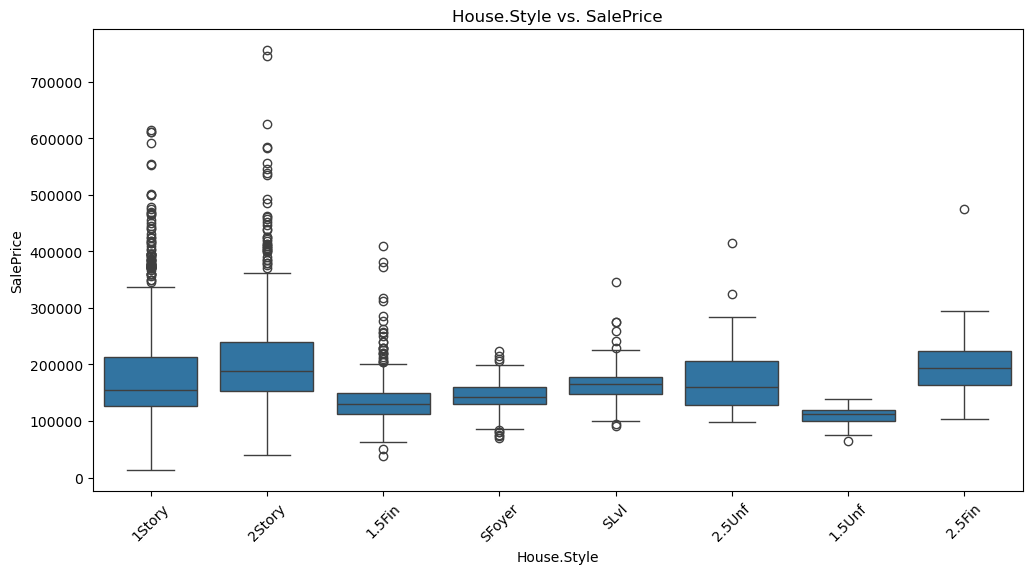

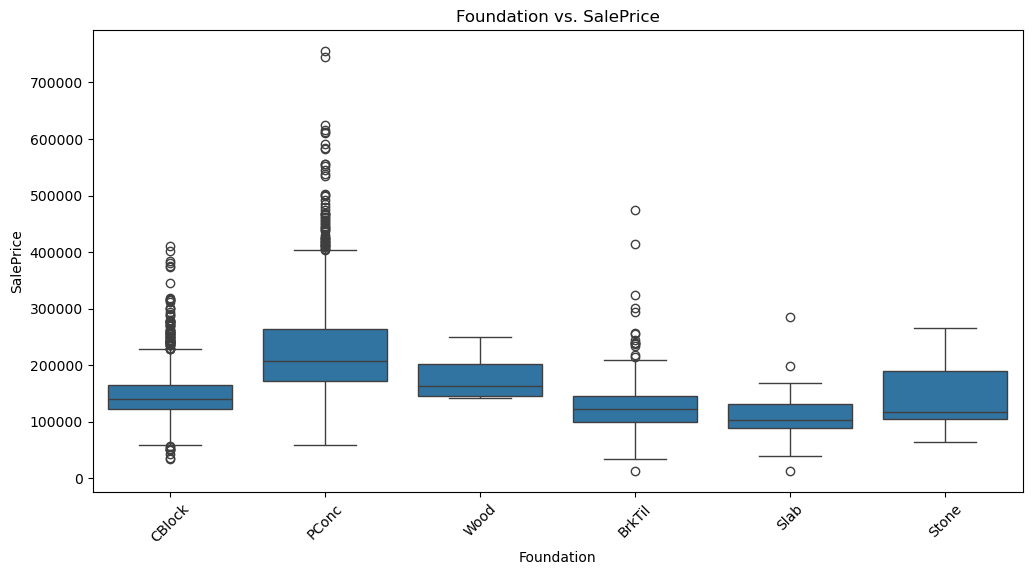

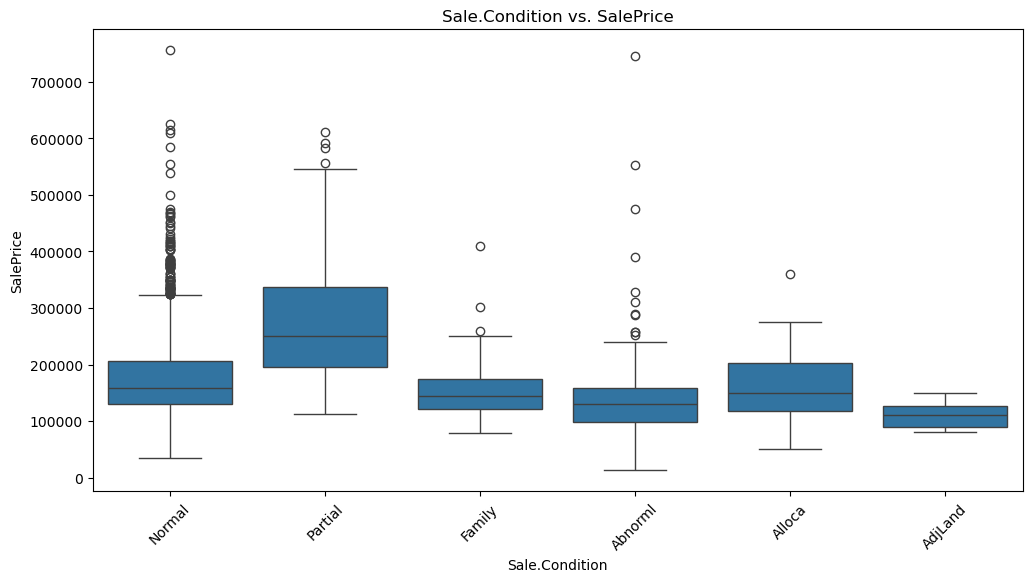

In [23]:
categorical_features_to_compare = [
    "Neighborhood",
    "Bldg.Type",
    "House.Style",
    "Foundation",
    "Sale.Condition"
]

for feature in categorical_features_to_compare:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x=feature, y="SalePrice")
    plt.title(f"{feature} vs. SalePrice")
    plt.xlabel(feature)
    plt.ylabel("SalePrice")
    plt.xticks(rotation=45)
    plt.show()

### Interpretation of Categorical Variables and Sale Price

Neighborhood has substantial variability in median sale price and the spread of sale prives. Building type also shows large differences. Single family homes have higher meidan sale prices typically. House Style, Foundation, and Sale Condition all seem to have similar variability. This is a good indicator that these features may be useful predictors of sale price and may need to be considered in the model. 